In [65]:
import pandas as pd
import numpy as np
from statsmodels.tsa.ar_model import AutoReg, ARResults, ar_select_order
from sklearn.metrics import mean_squared_error

,PopEst
DATE,
2011-01-01,311037
2011-02-01,311189
2011-03-01,311351
2011-04-01,311522
2011-05-01,311699


<Axes: xlabel='DATE'>

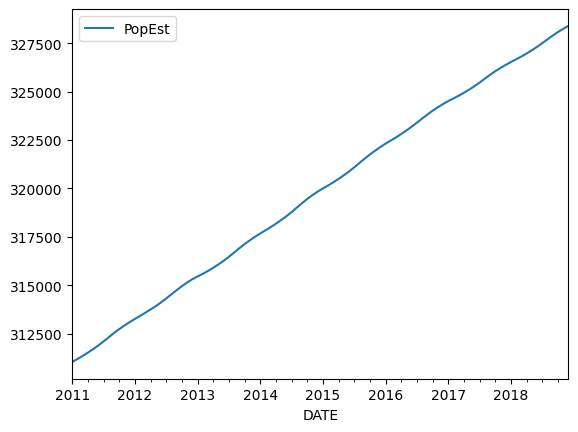

In [4]:
df = pd.read_csv('../data/uspopulation.csv', index_col='DATE', parse_dates=True)
df.index.freq = 'MS'
display(df.head())
df.plot()

In [20]:
train = df.iloc[:84]
test = df.iloc[84:]
model = AutoReg(train["PopEst"], lags=1) # lags is the p parameter of AR(p), defines the orders of the model
AR1fit = model.fit()
print(AR1fit.summary())

                            AutoReg Model Results                             
Dep. Variable:                 PopEst   No. Observations:                   84
Model:                     AutoReg(1)   Log Likelihood                -380.819
Method:               Conditional MLE   S.D. of innovations             23.789
Date:                Wed, 18 Feb 2026   AIC                            767.638
Time:                        11:51:02   BIC                            774.894
Sample:                    02-01-2011   HQIC                           770.553
                         - 12-01-2017                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        284.9138    185.428      1.537      0.124     -78.518     648.346
PopEst.L1      0.9997      0.001   1718.076      0.000       0.999       1.001
                                    Roots           

In [24]:
AR1fit.params # the coefficients of the regression model for 1 lag

const        284.913797
PopEst.L1      0.999686
dtype: float64

<Axes: xlabel='DATE'>

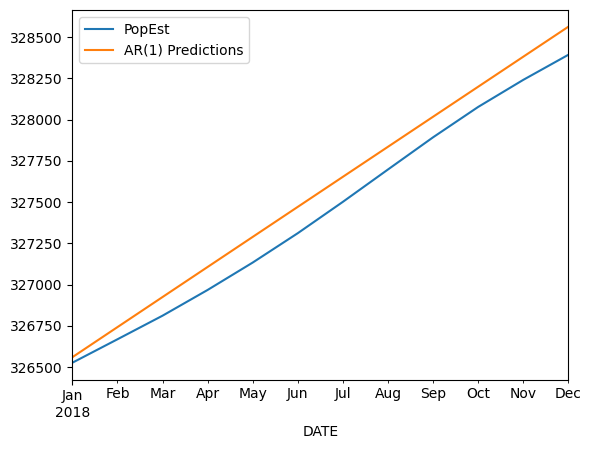

In [ ]:
predictions1 = AR1fit.predict(start=test.index[0], end=test.index[-1]) # predictions for the test set
predictions1.rename("AR(1) Predictions", inplace=True)
test.plot(legend=True)
predictions1.plot(legend=True)
# Bear in mind that here we are predicting just 1 one lag, so the model is not very good at predicting 
# since we are just using information from 1 month ago to predict the next month

In [43]:
AR2fit = AutoReg(train["PopEst"], lags=2).fit() # AR(2) model, using 2 lags
AR2fit.params

const        137.368305
PopEst.L1      1.853490
PopEst.L2     -0.853836
dtype: float64

<Axes: xlabel='DATE'>

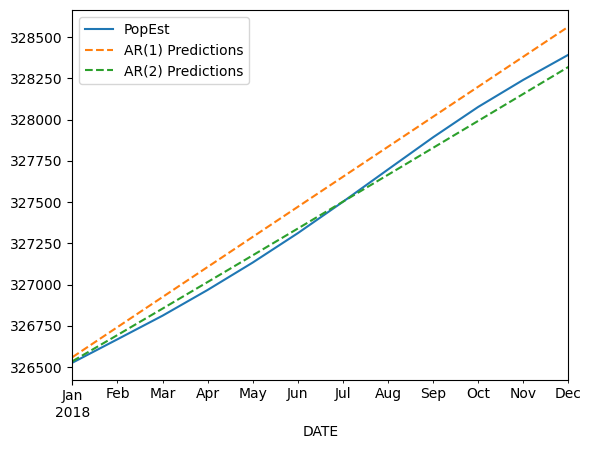

In [ ]:
predictions2 = AR2fit.predict(start=test.index[0], end=test.index[-1]) # predictions for the test set
predictions2.rename("AR(2) Predictions", inplace=True)
test.plot(legend=True)
predictions1.plot(legend=True, style='--')
predictions2.plot(legend=True, style='--') 

In [ ]:
# 1. Select the best lag order using an Information Criterion (aic, bic or hqic)
# aic has a lower penalty for adding more lags, and prioritizes capturing all possible patterns
# bic has a higher penalty for adding more lags, and prioritizes finding the true underlying process
# hqic is in between aic and bic
sel = ar_select_order(train["PopEst"], maxlag=10, ic='bic')

# 2. Fit the model using the automatically the best lag order selected in the previous step
#ARfit = sel.model.fit()
ARfit = AutoReg(train["PopEst"], lags=sel.ar_lags).fit()

# View the selected lags
print(f"Selected Lags: {sel.ar_lags}")

# Be careful, with maxlag=20, it selects 14 lags, but the MSE will be much higher than with 8 lags,
# so it seems that the model is overfitting the data. This happens because the best model is selected
# based on the training data, and it may not generalize well to the test data.

Selected Lags: [1, 2, 3, 4, 5, 6, 7, 8]


In [104]:
print(ARfit.summary())

                            AutoReg Model Results                             
Dep. Variable:                 PopEst   No. Observations:                   84
Model:                     AutoReg(8)   Log Likelihood                -234.177
Method:               Conditional MLE   S.D. of innovations              5.272
Date:                Wed, 18 Feb 2026   AIC                            488.353
Time:                        12:36:20   BIC                            511.660
Sample:                    09-01-2011   HQIC                           497.668
                         - 12-01-2017                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         82.3097     53.032      1.552      0.121     -21.632     186.251
PopEst.L1      2.4380      0.103     23.749      0.000       2.237       2.639
PopEst.L2     -2.3021      0.275     -8.384      0.0

<Axes: xlabel='DATE'>

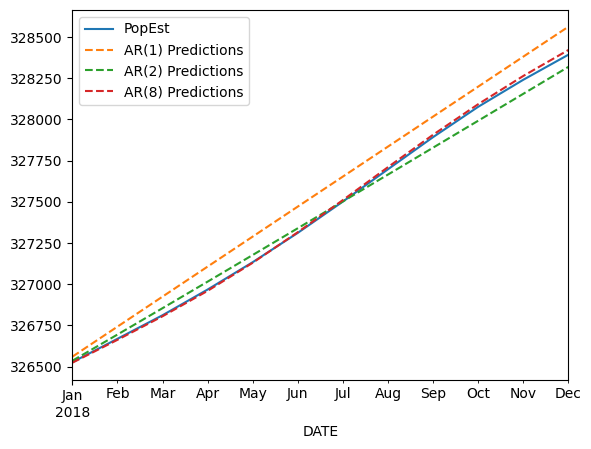

In [109]:
predictions8 = ARfit.predict(start=test.index[0], end=test.index[-1]) # predictions for the test set
predictions8.rename("AR(8) Predictions", inplace=True)
test.plot(legend=True)
predictions1.plot(legend=True, style='--')
predictions2.plot(legend=True, style='--') 
predictions8.plot(legend=True, style='--')

In [110]:
preds = [predictions1, predictions2, predictions8]
labels = ["AR(1)", "AR(2)", "AR(8)"]
for i in range(3):
    error = mean_squared_error(test["PopEst"], preds[i])
    print(f"{labels[i]} MSE: {error:.2f}")

AR(1) MSE: 17449.71
AR(2) MSE: 2713.26
AR(8) MSE: 186.97


<Axes: xlabel='DATE'>

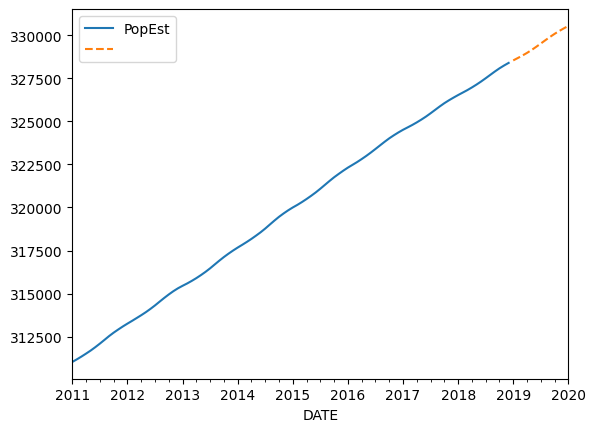

In [111]:
# forecast into the future
ARfit = AutoReg(df["PopEst"], lags=sel.ar_lags).fit() # fit the model using all the data
future_preds = ARfit.predict(start=len(df), end=len(df) + 12) # forecast for the next 12 months

df["PopEst"].plot(legend=True)
future_preds.plot(legend=True, style='--')